Import Library

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB # gausian naive bayers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df=pd.read_csv('/content/loan_risk_data.csv')

In [30]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


Data Cleaning


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [32]:
df.isnull().sum()*100/len(df)

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


In [41]:
df['Self_Employed'].fillna('Unknown',inplace=True)
df['Credit_History'].fillna(2.0,inplace=True)
df.dropna(subset=['Loan_Amount_Term','Dependents','Gender','Married'],inplace=True)

In [42]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Split X and y and train

In [56]:
X=df[['Education','Credit_History','Self_Employed','LoanAmount','Loan_Amount_Term','Property_Area','Married']]
y=df['Loan_Status']

In [58]:
X_test,X_train,y_test,y_train=train_test_split(X,y,test_size=0.3,random_state=42)

In [59]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (excluding 'Loan_ID' and target 'Loan_Status')
categorical_cols = X_train.select_dtypes(include='object').columns.drop(['Loan_ID'], errors='ignore').tolist()

# Encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Encode the target variable y
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

Using model

In [61]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

Checking accuracy

In [63]:
y_pred=model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy_percent = accuracy * 100

print(f"Accuracy: {accuracy_percent:.2f}%")

Accuracy: 66.67%


Evaluating using Confusion Matrix

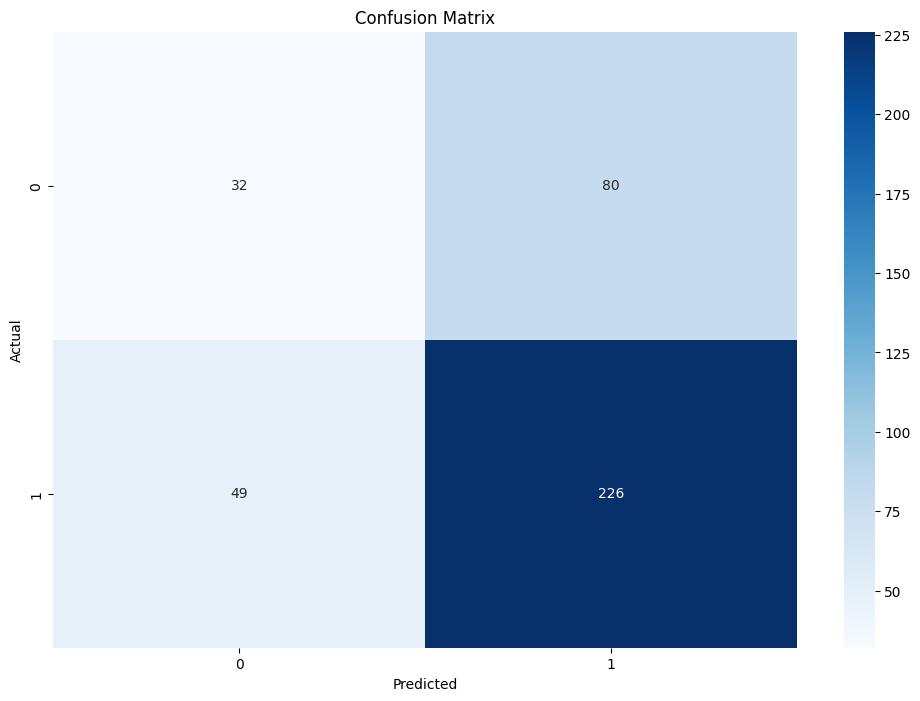

In [64]:
cm_matrix=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(12,8))

sns.heatmap(cm_matrix,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

## CONCLUSION
 The analysis shows the potential of using Naive Bayers Algo for this project prediction. The modle has achieved an accuracy of 66.67%, indiciating the overall correctness of its predictions on selected features .The confusion Matrix shows that the type of errors it makes .Despite the model meeting a resonable precentage of accuracy tuning it could improve its perfomance.
